# usv Data Proccessing

In [1]:
#imports and directory location
twentyfive_directory = "25_padded"
noise_directory = "noise_padded"
otherUSV_directory = "otherUSV_padded"

import numpy as np
from matplotlib import pyplot as plt
import cv2
import os #may need to pip install
import torch # may need to pip install
#import PIL
from PIL import Image

# define desired image resolution (HxW) and color option (RGB =3, greyscale = 1)
height = 64
width = 64
color = 3


In [2]:
#keeps kernal from dying when multiple OpenMP linked, use during debugging
#os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [3]:
#function that takes a directory of image files and returns a list of image np arrays
#direct = folder name, height = image pixel row count, weight = image pixel column count, chennels = color dimension
def image_dir_2_lst(direct, height, width, channels):
    # init lst var
    lst = []

    #iterate tthrough every file in the given folder
    for filename in os.listdir(direct):
        # skip macOS metadata files
        if filename.startswith("._"):
            continue
        #create join filepath in order to open image
        f = os.path.join(direct, filename)

        # enure what was pulled out of the directory is a useable file type
        if os.path.isfile(f) and f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            try:
                # load image file with PIL
                img = Image.open(f)

                # force consistancy in image file format
                if channels == 1:
                    img = img.convert("L") #greyscale
                elif channels == 3:
                    img = img.convert("RGB") # 3d color

                # resize images to be consistant for loading into a tensor
                #!!! PIL uses (width, height) unlike everything else that uses (height, width)
                img = img.resize((width, height))

                # convert to numpy array
                img = np.array(img)

                # ensure shape is correct, if it is, add it to the lst
                if img.shape == (height, width, channels) or (channels == 1 and img.shape == (height, width)):
                    lst.append(img)
            # skip non-image files
            except Exception:
                print("Skipping bad file:", filename)
    #return lst of image np arrays
    return lst

In [4]:
#run the image to array function on all categories (each folder= 1 category)
#images uploaded from local directory

twentyfive_lst = image_dir_2_lst(twentyfive_directory,height,width,color)
noise_lst = image_dir_2_lst(noise_directory,height,width,color)
otherUSV_lst = image_dir_2_lst(otherUSV_directory,height,width,color)

In [5]:
#Results are x lists hXw color images (3 channel) printing size should be (h,w,3) num of files in the folder
print(twentyfive_lst[0].shape, len(twentyfive_lst))
print(noise_lst[0].shape,len(noise_lst))
print(otherUSV_lst[0].shape,len(otherUSV_lst))


(64, 64, 3) 958
(64, 64, 3) 2635
(64, 64, 3) 2635


Sanity Check, print out an example from each list to ensure that what was copied was correct

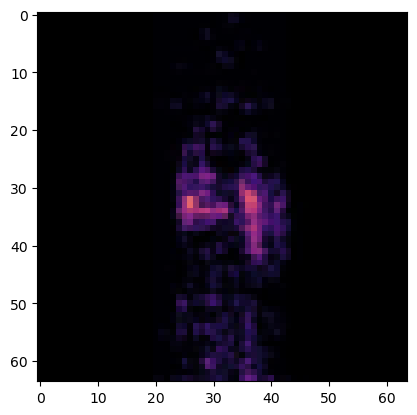

In [6]:
plt.imshow(twentyfive_lst[509])
plt.show()

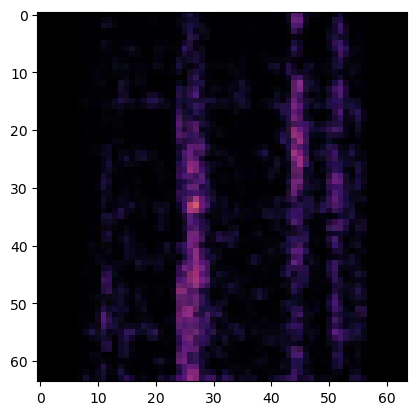

In [7]:
plt.imshow(noise_lst[936])
plt.show()

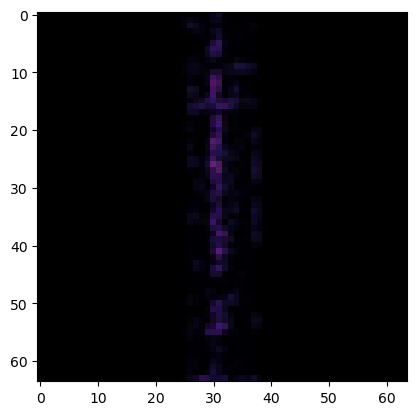

In [8]:
plt.imshow(otherUSV_lst[0])
plt.show()

In [9]:
#combine all lists and convert to one large np array

# concat lists
combo_lst = twentyfive_lst+noise_lst+otherUSV_lst
#convert to single 4d np array (number of images, h, w, channels)
X = np.asarray(combo_lst)

In [11]:
#create label list for each category and then combine into an array
twentyfive_labels = [0]*len(twentyfive_lst)
noise_labels = [1]*len(noise_lst)
otherUSV_labels = [2]*len(otherUSV_lst)


#combine into one list of labels and change into an array
combo_labels_lst = twentyfive_labels+noise_labels+otherUSV_labels
Y = np.asarray(combo_labels_lst)

In [12]:
#sanity check
Y.shape

(6228,)

In [13]:
#Save data and label np files
np.save("usv_imgs", X)
np.save("usv_labels",Y)